In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io
import time

In [2]:
np.random.seed(42)

In [3]:
# CONFIG

TRAIN_PATH = "/content/train-00000-of-00001.parquet"
TEST_PATH = "/content/test-00000-of-00001.parquet"

LEARNING_RATE = 0.05
BATCH_SIZE = 32
EPOCHS = 5
TRAIN_SUBSET = 10000

In [4]:
# UTILITY FUNCTIONS

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)



def cross_entropy(predictions, labels):
    n = labels.shape[0]
    probs = predictions[np.arange(n), labels]
    return -np.mean(np.log(probs + 1e-9))



def accuracy(predictions, labels):
    preds = np.argmax(predictions, axis=1)
    return np.mean(preds == labels)


In [5]:
# CONVOLUTION LAYER

class ConvLayer:
    def __init__(self, num_filters, filter_size, input_depth):

        self.num_filters = num_filters
        self.filter_size = filter_size
        self.input_depth = input_depth

        self.filters = np.random.randn(
            num_filters,
            input_depth,
            filter_size,
            filter_size,
        ) * np.sqrt(2.0 / (filter_size * filter_size * input_depth))

        self.biases = np.zeros((num_filters,))

    def forward(self, input_data):

        self.input = input_data

        batch_size, depth, height, width = input_data.shape

        output_height = height - self.filter_size + 1
        output_width = width - self.filter_size + 1

        output = np.zeros(
            (
                batch_size,
                self.num_filters,
                output_height,
                output_width,
            )
        )

        for b in range(batch_size):
            for f in range(self.num_filters):
                for i in range(output_height):
                    for j in range(output_width):

                        region = input_data[
                            b,
                            :,
                            i:i+self.filter_size,
                            j:j+self.filter_size,
                        ]

                        output[b, f, i, j] = (
                            np.sum(region * self.filters[f])
                            + self.biases[f]
                        )

        self.output = output

        return output

    def backward(self, d_out, learning_rate):

        batch_size, depth, height, width = self.input.shape

        output_height = height - self.filter_size + 1
        output_width = width - self.filter_size + 1

        d_filters = np.zeros_like(self.filters)
        d_biases = np.zeros_like(self.biases)
        d_input = np.zeros_like(self.input)

        for b in range(batch_size):
            for f in range(self.num_filters):
                for i in range(output_height):
                    for j in range(output_width):

                        region = self.input[
                            b,
                            :,
                            i:i+self.filter_size,
                            j:j+self.filter_size,
                        ]

                        d_filters[f] += d_out[b, f, i, j] * region

                        d_input[
                            b,
                            :,
                            i:i+self.filter_size,
                            j:j+self.filter_size,
                        ] += d_out[b, f, i, j] * self.filters[f]

                        d_biases[f] += d_out[b, f, i, j]

        self.filters -= learning_rate * d_filters / batch_size
        self.biases -= learning_rate * d_biases / batch_size

        return d_input


In [6]:
# RELU


class ReLU:

    def forward(self, input_data):
        self.input = input_data
        return np.maximum(0, input_data)

    def backward(self, d_out):

        grad = d_out.copy()
        grad[self.input <= 0] = 0

        return grad


In [7]:
# MAXPOOL

class MaxPool:

    def __init__(self, size=2, stride=2):
        self.size = size
        self.stride = stride

    def forward(self, input_data):

        self.input = input_data

        batch_size, depth, height, width = input_data.shape

        out_height = height // self.size
        out_width = width // self.size

        output = np.zeros((batch_size, depth, out_height, out_width))

        for b in range(batch_size):
            for d in range(depth):
                for i in range(out_height):
                    for j in range(out_width):

                        region = input_data[
                            b,
                            d,
                            i*self.stride:i*self.stride+self.size,
                            j*self.stride:j*self.stride+self.size,
                        ]

                        output[b, d, i, j] = np.max(region)

        return output

    def backward(self, d_out):

        batch_size, depth, height, width = self.input.shape

        out_height = height // self.size
        out_width = width // self.size

        d_input = np.zeros_like(self.input)

        for b in range(batch_size):
            for d in range(depth):
                for i in range(out_height):
                    for j in range(out_width):

                        region = self.input[
                            b,
                            d,
                            i*self.stride:i*self.stride+self.size,
                            j*self.stride:j*self.stride+self.size,
                        ]

                        max_val = np.max(region)

                        for m in range(self.size):
                            for n in range(self.size):
                              if (
                                  region[m, n] == max_val
                                  and d_input[
                                      b,
                                      d,
                                      i*self.stride+m,
                                      j*self.stride+n,
                                      ] == 0
                                  ):
                                    d_input[
                                        b,
                                        d,
                                        i*self.stride+m,
                                        j*self.stride+n,
                                    ] = d_out[b, d, i, j]

        return d_input


In [8]:
# FLATTEN

class Flatten:

    def forward(self, input_data):
        self.input_shape = input_data.shape
        return input_data.reshape(input_data.shape[0], -1)

    def backward(self, d_out):
        return d_out.reshape(self.input_shape)


In [9]:
# FULLY CONNECTED LAYER

class FullyConnected:

    def __init__(self, input_size, output_size):

        self.weights = np.random.randn(
            input_size,
            output_size,
        ) * np.sqrt(2.0 / input_size)

        self.biases = np.zeros((1, output_size))

    def forward(self, input_data):

        self.input = input_data

        return np.dot(input_data, self.weights) + self.biases

    def backward(self, d_out, learning_rate):

        d_weights = np.dot(self.input.T, d_out)
        d_biases = np.sum(d_out, axis=0, keepdims=True)

        d_input = np.dot(d_out, self.weights.T)

        self.weights -= learning_rate * d_weights / self.input.shape[0]
        self.biases -= learning_rate * d_biases / self.input.shape[0]

        return d_input



In [10]:
# CNN MODEL

class CNN:

    def __init__(self):

        # Increased capacity
        self.conv1 = ConvLayer(16, 3, 1)
        self.relu1 = ReLU()
        self.pool1 = MaxPool()

        self.conv2 = ConvLayer(32, 3, 16)
        self.relu2 = ReLU()
        self.pool2 = MaxPool()

        self.flatten = Flatten()

        # Shape calculation:
        # 28 -> 26 -> 13 -> 11 -> 5
        # 32 x 5 x 5 = 800

        self.fc1 = FullyConnected(800, 64)
        self.relu3 = ReLU()

        self.fc2 = FullyConnected(64, 10)

    def forward(self, x):

        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        x = self.flatten.forward(x)

        x = self.fc1.forward(x)
        x = self.relu3.forward(x)

        logits = self.fc2.forward(x)

        return softmax(logits)

    def backward(self, predictions, labels, learning_rate):

        batch_size = labels.shape[0]

        grad = predictions.copy()

        grad[np.arange(batch_size), labels] -= 1

        # IMPORTANT:
        # DO NOT divide by batch_size here.
        # Gradients are already averaged during updates.

        grad = self.fc2.backward(grad, learning_rate)

        grad = self.relu3.backward(grad)
        grad = self.fc1.backward(grad, learning_rate)

        grad = self.flatten.backward(grad)

        grad = self.pool2.backward(grad)
        grad = self.relu2.backward(grad)
        grad = self.conv2.backward(grad, learning_rate)

        grad = self.pool1.backward(grad)
        grad = self.relu1.backward(grad)
        grad = self.conv1.backward(grad, learning_rate)

In [11]:
# DATA LOADING

print("Loading data...")

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)


# Decode PNG bytes from parquet

def decode_image(image_dict):

    image_bytes = image_dict['bytes']

    image = Image.open(io.BytesIO(image_bytes)).convert('L')

    image = np.array(image, dtype=np.float32)

    return image


X_train = np.array(
    [decode_image(img) for img in train_df['image']],
    dtype=np.float32,
)

y_train = np.array(train_df['label'].tolist())

X_test = np.array(
    [decode_image(img) for img in test_df['image']],
    dtype=np.float32,
)

y_test = np.array(test_df['label'].tolist())


# Normalize
X_train /= 255.0
X_test /= 255.0


# Reshape
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)


# Use subset for speed
X_train = X_train[:TRAIN_SUBSET]
y_train = y_train[:TRAIN_SUBSET]


# Validation split
split_idx = int(0.9 * len(X_train))

X_val = X_train[split_idx:]
y_val = y_train[split_idx:]

X_train = X_train[:split_idx]
y_train = y_train[:split_idx]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Loading data...
Train: (9000, 1, 28, 28)
Validation: (1000, 1, 28, 28)
Test: (10000, 1, 28, 28)


In [12]:
# PARAMETER COUNT

n_params = (
    (16 * 1 * 3 * 3 + 16)
    + (32 * 16 * 3 * 3 + 32)
    + (800 * 64 + 64)
    + (64 * 10 + 10)
)
print(f"\nTotal Parameters: {n_params}")



Total Parameters: 56714


In [13]:
# TRAINING

model = CNN()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

start_time = time.time()

num_samples = len(X_train)

print("\nStarting training...\n")

for epoch in range(EPOCHS):

    indices = np.random.permutation(num_samples)

    X_train = X_train[indices]
    y_train = y_train[indices]

    total_loss = 0
    total_acc = 0

    n_batches = 0

    for i in range(0, num_samples, BATCH_SIZE):

        X_batch = X_train[i:i+BATCH_SIZE]
        y_batch = y_train[i:i+BATCH_SIZE]

        predictions = model.forward(X_batch)

        loss = cross_entropy(predictions, y_batch)
        acc = accuracy(predictions, y_batch)

        total_loss += loss
        total_acc += acc

        model.backward(predictions, y_batch, LEARNING_RATE)

        n_batches += 1

        if i % 320 == 0:
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Step {i}/{num_samples} | "
                f"Loss {loss:.4f} | "
                f"Acc {acc:.4f}"
            )

    avg_train_loss = total_loss / n_batches
    avg_train_acc = total_acc / n_batches

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)


    # Validation
    val_predictions = model.forward(X_val)

    val_loss = cross_entropy(val_predictions, y_val)
    val_acc = accuracy(val_predictions, y_val)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print("\n" + "=" * 60)
    print(f"Epoch {epoch+1} Completed")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Accuracy: {avg_train_acc:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("=" * 60 + "\n")


training_time = (time.time() - start_time) / 60

print(f"Training Time: {training_time:.2f} minutes")



Starting training...

Epoch 1/5 | Step 0/9000 | Loss 2.6155 | Acc 0.1250
Epoch 1/5 | Step 320/9000 | Loss 1.7673 | Acc 0.4062
Epoch 1/5 | Step 640/9000 | Loss 1.3184 | Acc 0.6250
Epoch 1/5 | Step 960/9000 | Loss 1.2272 | Acc 0.4375
Epoch 1/5 | Step 1280/9000 | Loss 0.7493 | Acc 0.7500
Epoch 1/5 | Step 1600/9000 | Loss 0.8307 | Acc 0.7500
Epoch 1/5 | Step 1920/9000 | Loss 0.7142 | Acc 0.8125
Epoch 1/5 | Step 2240/9000 | Loss 0.4082 | Acc 0.8438
Epoch 1/5 | Step 2560/9000 | Loss 0.3714 | Acc 0.9062
Epoch 1/5 | Step 2880/9000 | Loss 0.5722 | Acc 0.8438
Epoch 1/5 | Step 3200/9000 | Loss 0.7201 | Acc 0.8438
Epoch 1/5 | Step 3520/9000 | Loss 0.2446 | Acc 0.9062
Epoch 1/5 | Step 3840/9000 | Loss 0.2132 | Acc 0.9688
Epoch 1/5 | Step 4160/9000 | Loss 0.5110 | Acc 0.7812
Epoch 1/5 | Step 4480/9000 | Loss 0.2173 | Acc 0.9062
Epoch 1/5 | Step 4800/9000 | Loss 0.2747 | Acc 0.8438
Epoch 1/5 | Step 5120/9000 | Loss 0.1363 | Acc 0.9688
Epoch 1/5 | Step 5440/9000 | Loss 0.1694 | Acc 0.9375
Epoch 1/5 |

In [14]:
# TEST EVALUATION

print("\nEvaluating on test set...")

predictions = model.forward(X_test)

final_test_accuracy = accuracy(predictions, y_test)

print(f"Final Test Accuracy: {final_test_accuracy:.4f}")




Evaluating on test set...
Final Test Accuracy: 0.9722


In [17]:
from sklearn.metrics import confusion_matrix

# Convert predictions to class labels
pred_classes = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(y_test, pred_classes)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 963    0    2    1    1    0    7    1    3    2]
 [   0 1121    4    1    0    0    4    1    3    1]
 [   1    2 1005    7    2    0    0   11    4    0]
 [   0    0    3  995    0    1    0    3    4    4]
 [   1    2    1    0  953    0    1    1    2   21]
 [   1    1    1   29    0  829   10    3   10    8]
 [   5    3    1    1    5    1  940    0    2    0]
 [   0    2   13    2    1    1    0  995    1   13]
 [   2    0    3   10    2    0    3    8  932   14]
 [   3    3    0    0    4    0    0    8    2  989]]


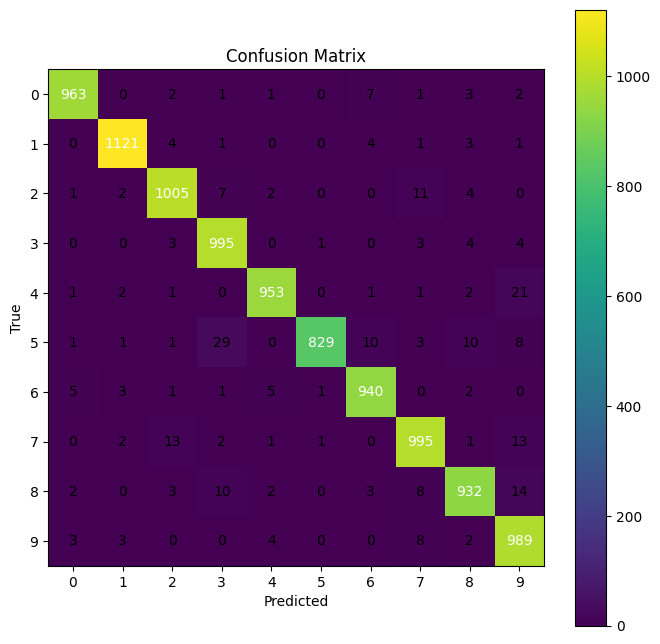

In [31]:
# CONFUSION MATRIX PLOT

plt.figure(figsize=(8, 8))

plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(10):
    for j in range(10):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > cm.max()/2 else 'black'
        )

plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar()
plt.savefig('confusion_matrix.jpg') # Save the plot as JPG
plt.show()

In [19]:
# PER-CLASS ACCURACY

print("\nPer-Class Accuracy")
print("-" * 30)

for digit in range(10):

    total = cm[digit].sum()
    correct = cm[digit, digit]

    class_acc = 100 * correct / total

    print(
        f"Digit {digit}: "
        f"{correct}/{total} "
        f"= {class_acc:.2f}%"
    )



Per-Class Accuracy
------------------------------
Digit 0: 963/980 = 98.27%
Digit 1: 1121/1135 = 98.77%
Digit 2: 1005/1032 = 97.38%
Digit 3: 995/1010 = 98.51%
Digit 4: 953/982 = 97.05%
Digit 5: 829/892 = 92.94%
Digit 6: 940/958 = 98.12%
Digit 7: 995/1028 = 96.79%
Digit 8: 932/974 = 95.69%
Digit 9: 989/1009 = 98.02%


In [20]:
# SAVE METRICS

np.save("train_losses.npy", train_losses)
np.save("train_accuracies.npy", train_accuracies)
np.save("val_losses.npy", val_losses)
np.save("val_accuracies.npy", val_accuracies)




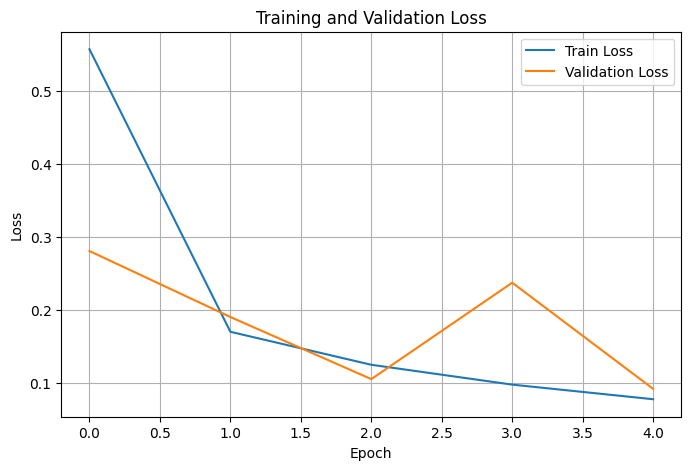

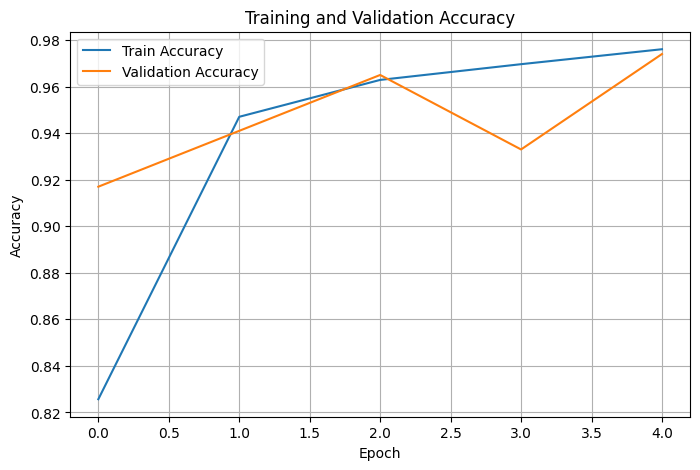

In [32]:
# PLOT TRAINING CURVES

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_validation_loss.jpg') # Save the plot as JPG
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('training_validation_accuracy.jpg') # Save the plot as JPG
plt.show()

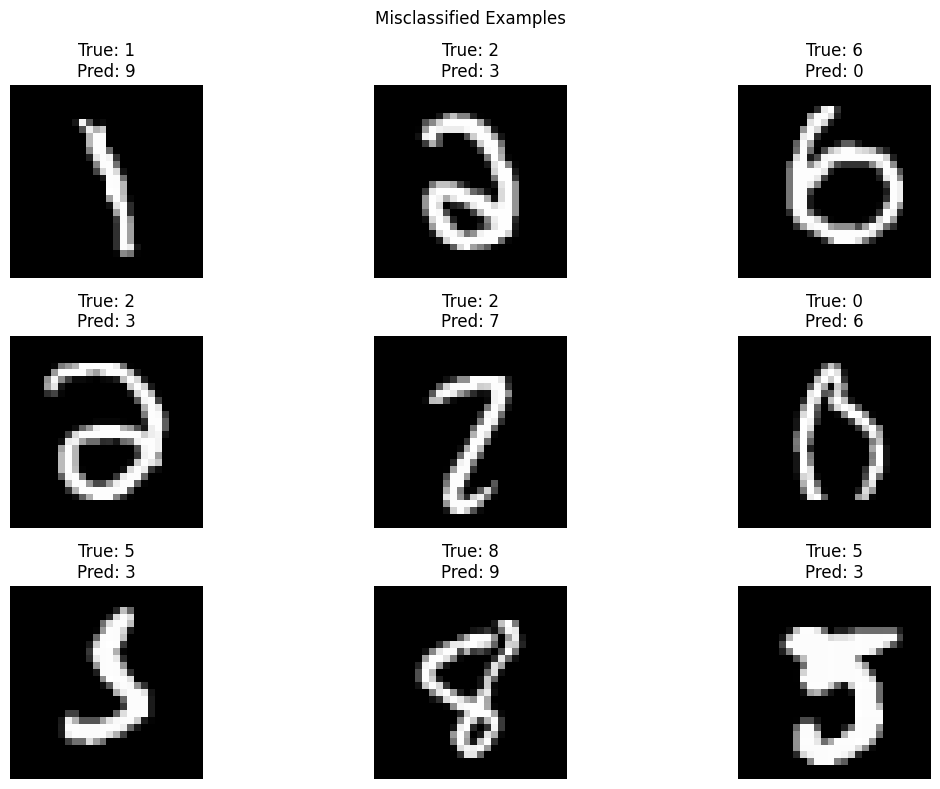

In [33]:
wrong = np.where(pred_classes != y_test)[0]

plt.figure(figsize=(12, 8))

for i in range(min(9, len(wrong))):

    idx = wrong[i]

    plt.subplot(3, 3, i+1)

    plt.imshow(X_test[idx][0], cmap='gray')

    plt.title(
        f"True: {y_test[idx]}\nPred: {pred_classes[idx]}"
    )

    plt.axis('off')

plt.suptitle('Misclassified Examples')
plt.tight_layout()
plt.savefig('misclassified_examples.jpg') # Save the plot as JPG
plt.show()

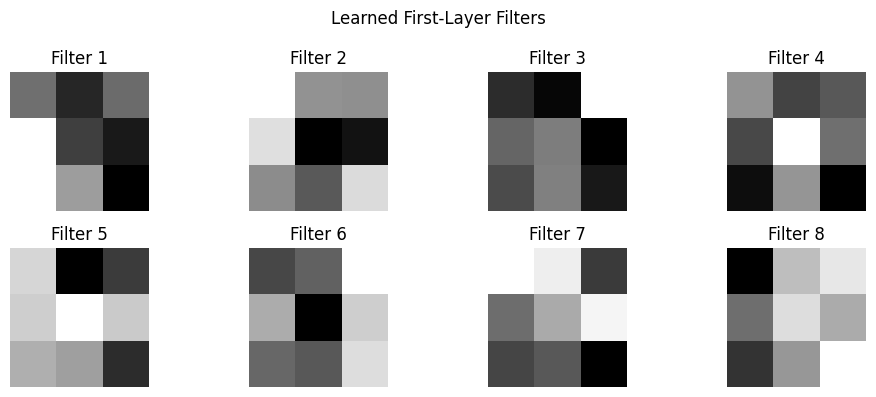

In [34]:
filters = model.conv1.filters

plt.figure(figsize=(10, 4))

# Adjust the loop to only show the first 8 filters to fit the (2, 4) subplot grid
for i in range(min(filters.shape[0], 8)):

    plt.subplot(2, 4, i+1)

    plt.imshow(filters[i, 0], cmap='gray')

    plt.title(f'Filter {i+1}')

    plt.axis('off')

plt.suptitle('Learned First-Layer Filters')
plt.tight_layout()
plt.savefig('learned_filters.jpg') # Save the plot as JPG
plt.show()

In [26]:
# SIMPLE MLP BASELINE

class SimpleMLP:

    def __init__(self):

        self.W1 = np.random.randn(784, 128) * np.sqrt(2.0 / 784)
        self.b1 = np.zeros((1, 128))

        self.W2 = np.random.randn(128, 10) * np.sqrt(2.0 / 128)
        self.b2 = np.zeros((1, 10))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_grad(self, x):
        grad = np.ones_like(x)
        grad[x <= 0] = 0
        return grad

    def forward(self, x):

        self.x = x.reshape(x.shape[0], -1)

        self.z1 = np.dot(self.x, self.W1) + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2

        return softmax(self.z2)

    def backward(self, preds, labels, lr):

        batch_size = labels.shape[0]

        grad = preds.copy()
        grad[np.arange(batch_size), labels] -= 1
        grad /= batch_size

        dW2 = np.dot(self.a1.T, grad)
        db2 = np.sum(grad, axis=0, keepdims=True)

        da1 = np.dot(grad, self.W2.T)
        dz1 = da1 * self.relu_grad(self.z1)

        dW1 = np.dot(self.x.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        self.W2 -= lr * dW2
        self.b2 -= lr * db2

        self.W1 -= lr * dW1
        self.b1 -= lr * db1


print("\nTraining MLP baseline...")

mlp = SimpleMLP()

for epoch in range(3):

    for i in range(0, len(X_train), BATCH_SIZE):

        X_batch = X_train[i:i+BATCH_SIZE]
        y_batch = y_train[i:i+BATCH_SIZE]

        preds = mlp.forward(X_batch)

        mlp.backward(preds, y_batch, LEARNING_RATE)


mlp_preds = mlp.forward(X_test)
mlp_acc = accuracy(mlp_preds, y_test)

print(f"MLP Accuracy: {mlp_acc:.4f}")
print(f"CNN Accuracy: {final_test_accuracy:.4f}")





Training MLP baseline...
MLP Accuracy: 0.9103
CNN Accuracy: 0.9722


In [36]:
# FINAL SUMMARY

mlp_params = 784*128 + 128 + 128*10 + 10   # = 101,770

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"CNN Test Accuracy: {final_test_accuracy:.4f}")
print(f"MLP Test Accuracy: {mlp_acc:.4f}")
print(f"CNN Parameters:    {n_params}")
print(f"MLP Parameters:    {mlp_params}")
print(f"MLP / CNN ratio:   {mlp_params/n_params:.1f}x")
print(f"Training Time:     {training_time:.2f} minutes")
print("=" * 60)


FINAL RESULTS
CNN Test Accuracy: 0.9722
MLP Test Accuracy: 0.9103
CNN Parameters:    56714
MLP Parameters:    101770
MLP / CNN ratio:   1.8x
Training Time:     268.88 minutes
